# 2. Modelling and evaluation

Baseline first, then the model that ships, judged on the metric that matches the
cost of being wrong. The training code itself lives in
`src/predmaint/models/train.py`; this notebook is the readable trace of it.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

import pandas as pd
import plotly.io as pio

# Static images: GitHub does not render interactive Plotly output in notebooks.
pio.renderers.default = "png"

from predmaint.models.train import train_models

report = train_models(subset="FD001")
print(f"{report['n_features']} features, trained in {report['train_seconds']}s")

169 features, trained in 18.25s


## Cross-validated: what the trend features bought

Five GroupKFold folds, split on engine id. A random split would leak: cycle 41
and cycle 42 of the same engine are nearly identical rows.

In [2]:
cv = report["cv"]
pd.DataFrame(
    {
        "Ridge on snapshot": cv["baseline"],
        "Gradient boosting + trend": cv["model"],
    }
).loc[["rmse", "mae", "nasa_score_per_engine", "late_prediction_rate"]]

,Ridge on snapshot,Gradient boosting + trend
rmse,17.046554,12.551122
mae,13.800339,8.614275
nasa_score_per_engine,4.865901,2.866086
late_prediction_rate,0.483595,0.439288


## Held-out engines

Scored at the last observed cycle of each test engine, which is exactly the
question asked in production.

In [3]:
pd.DataFrame(
    {
        "Ridge on snapshot": report["test"]["baseline"],
        "Gradient boosting + trend": report["test"]["model"],
    }
).loc[["rmse", "mae", "nasa_score_per_engine", "late_prediction_rate"]]

,Ridge on snapshot,Gradient boosting + trend
rmse,18.248213,13.813285
mae,14.902888,10.080659
nasa_score_per_engine,5.043873,2.814650
late_prediction_rate,0.530000,0.470000


## The alert head

Recall is the number that matters: a missed at-risk engine is the expensive
error, an unnecessary inspection is not.

In [4]:
pd.Series(report["test"]["risk"])

roc_auc            0.993600
pr_auc             0.979599
precision          0.925926
recall             1.000000
f1                 0.961538
positive_rate      0.250000
threshold          0.500000
n                100.000000
dtype: float64

## Diagnostics

Where the errors are, and on which side of the diagonal they fall.

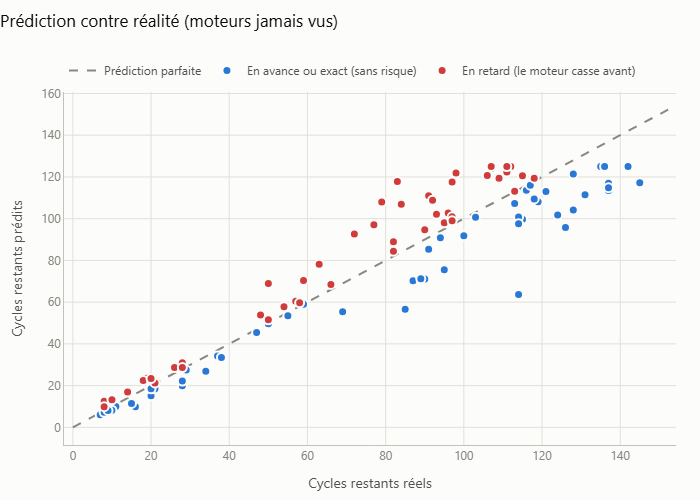

In [5]:
from predmaint.config import MODEL_CONFIG, RUL_COL, UNIT_COL
from predmaint.data.loader import load_subset
from predmaint.features.build import clip_rul, last_cycle_snapshot
from predmaint.models.predict import load_predictor
from predmaint.viz.plots import error_distribution, fleet_risk_bar, prediction_vs_actual

_, test = load_subset("FD001")
predictor = load_predictor()
fleet = predictor.score_fleet(test)

# Graded against the true remaining cycles, not the clipped training target:
# that is the published C-MAPSS protocol, and what train.py reports.
truth = last_cycle_snapshot(test).sort_values(UNIT_COL)[RUL_COL].to_numpy(dtype=float)
preds = fleet.sort_values(UNIT_COL)["predicted_rul"].to_numpy()

prediction_vs_actual(truth, preds)

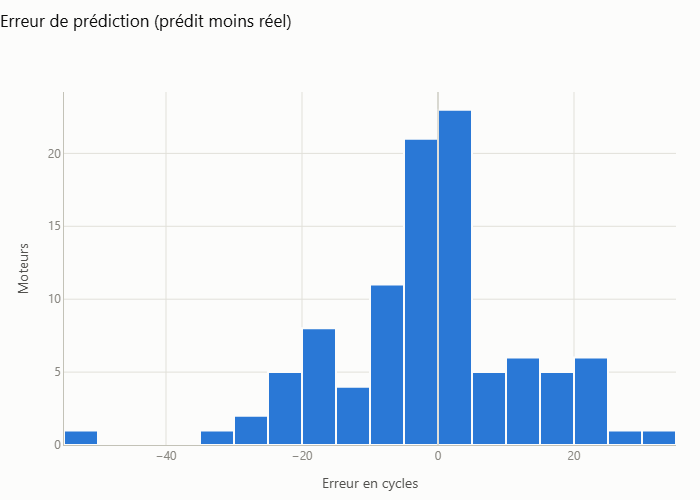

In [6]:
error_distribution(truth, preds)

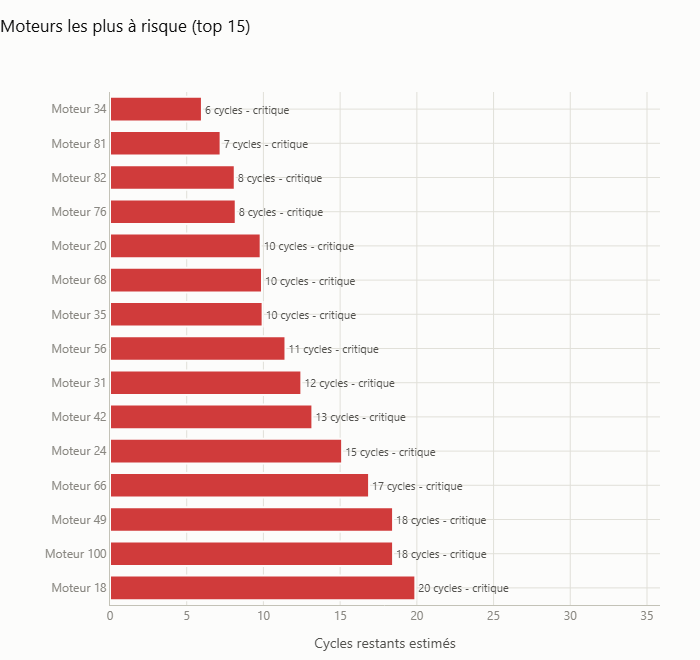

In [7]:
fleet_risk_bar(fleet)

## What the model leans on

Permutation importance on held-out engines. Slow but honest: it measures the
drop in score when a feature is shuffled, not a split count.

In [8]:
from sklearn.inspection import permutation_importance

from predmaint.features.build import build_features

snapshot = last_cycle_snapshot(build_features(test, predictor.sensors))
importance = permutation_importance(
    predictor.regressor,
    snapshot[predictor.features],
    clip_rul(snapshot[RUL_COL], MODEL_CONFIG.rul_cap),
    n_repeats=5,
    random_state=42,
    scoring="neg_root_mean_squared_error",
)
pd.Series(importance.importances_mean, index=predictor.features).nlargest(15)

cycle                2.831429
sensor_11_drift      2.262522
sensor_9_drift       1.935631
sensor_4_mean_10     0.849786
sensor_14_drift      0.646379
sensor_15_mean_10    0.411614
sensor_2_mean_10     0.405242
sensor_4_drift       0.339804
sensor_7_drift       0.329163
sensor_8_drift       0.327368
sensor_21_drift      0.313882
sensor_4_mean_5      0.224840
sensor_11_mean_5     0.214347
sensor_13_drift      0.200583
sensor_9_mean_10     0.190662
dtype: float64